In [20]:
from sklearn.datasets import fetch_olivetti_faces

data = fetch_olivetti_faces()

In [21]:
data.images.shape

(400, 64, 64)

In [22]:
train_images = data.images[:300]
test_images = data.images[300:]

In [23]:
import numpy as np
import pandas as pd


def mkPair(images, no_person):
    pairs = []

    for p in range(no_person):

        person_imgs = images[p * 10 : (p + 1) * 10]

        # 10 positive pairs
        for _ in range(10):
            i, j = np.random.choice(10, 2, replace=False)

            pairs.append([person_imgs[i], person_imgs[j], 1])

        # 10 negative pairs
        for _ in range(10):

            other_p = np.random.choice([x for x in range(no_person) if x != p])

            other_imgs = images[other_p * 10 : (other_p + 1) * 10]

            i = np.random.randint(10)
            j = np.random.randint(10)

            pairs.append([person_imgs[i], other_imgs[j], 0])

    return pd.DataFrame(pairs, columns=["img1", "img2", "label"])

In [24]:
train_pairs = mkPair(train_images, 30)
test_pairs = mkPair(test_images, 10)

In [25]:
# shuffle the dataset
train_pairs = train_pairs.sample(frac=1, random_state=42).reset_index(drop=True)
test_pairs = test_pairs.sample(frac=1, random_state=42).reset_index(drop=True)

In [26]:
y_train = train_pairs["label"]
X_train = train_pairs.drop(columns=["label"])
y_test = test_pairs["label"]
X_test = test_pairs.drop(columns=["label"])

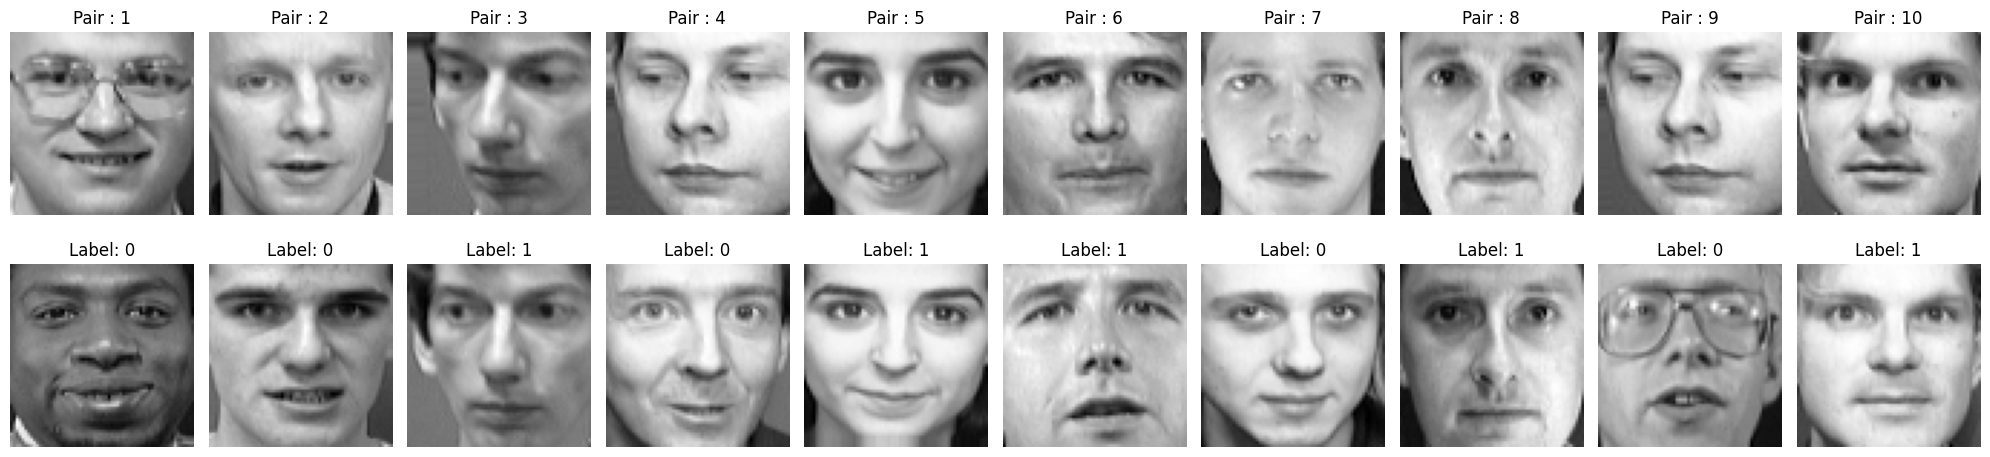

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 10, figsize=(20, 5))

for i in range(10):
    img1 = X_train.iloc[i]["img1"]
    img2 = X_train.iloc[i]["img2"]
    label = y_train.iloc[i]

    axes[0, i].imshow(img1, cmap="gray")
    axes[0, i].axis("off")

    axes[1, i].imshow(img2, cmap="gray")
    axes[1, i].axis("off")

    axes[1, i].set_title(f"Label: {label}")
    axes[0, i].set_title(f"Pair : {i+1}")

plt.tight_layout()
plt.show()

In [28]:
np.unique_counts(y_train)

UniqueCountsResult(values=array([0, 1]), counts=array([300, 300]))

In [29]:
np.unique_counts(y_test)

UniqueCountsResult(values=array([0, 1]), counts=array([100, 100]))

In [30]:
# CNN Code
class Conv2D:
    def __init__(self, in_channel, out_channel, kernal=3, stride=1, padding=0):
        self.in_channel = in_channel
        self.out_channel = out_channel
        self.kernal = kernal
        self.stride = stride
        self.padding = padding

        self.weights = np.random.randn(out_channel, in_channel, kernal, kernal)
        self.bias = np.zeros(out_channel)

    def forward(self, X):
        N, C, H, W = X.shape

        x_padded = np.pad(
            X,
            (
                (0, 0),
                (0, 0),
                (self.padding, self.padding),
                (self.padding, self.padding),
            ),
            mode="constant",
        )

        O_H = ((H + 2 * self.padding - self.kernal) // self.stride) + 1
        O_W = ((W + 2 * self.padding - self.kernal) // self.stride) + 1

        output = np.zeros((N, self.out_channel, O_H, O_W))

        for n in range(N):
            for oc in range(self.out_channel):
                for i in range(O_H):
                    for j in range(O_W):
                        h_start = i * self.stride
                        w_start = j * self.stride

                        h_end = h_start + self.kernal
                        w_end = w_start + self.kernal

                        output[n, oc, i, j] = (
                            np.sum(
                                x_padded[n, :, h_start:h_end, w_start:w_end]
                                * self.weights[oc]
                            )
                            + self.bias[oc]
                        )

        self.input = (X, x_padded)

        return output

    def backward(self, dvals):
        X, x_padded = self.input
        N, _, _, _ = X.shape
        _, _, H_OUT, W_OUT = dvals.shape

        self.dweights = np.zeros_like(self.weights)
        self.dbias = np.sum(dvals, axis=(0, 2, 3))

        grad_input = np.zeros_like(x_padded)

        for n in range(N):
            for oc in range(self.out_channel):
                for i in range(H_OUT):
                    for j in range(W_OUT):
                        h_start = i * self.stride
                        w_start = j * self.stride

                        h_end = h_start + self.kernal
                        w_end = w_start + self.kernal

                        self.dweights[oc] += (
                            dvals[n, oc, i, j]
                            * x_padded[n, :, h_start:h_end, w_start:w_end]
                        )
                        grad_input[n, :, h_start:h_end, w_start:w_end] += (
                            dvals[n, oc, i, j] * self.weights[oc]
                        )

        # Remove padding from gradient
        if self.padding > 0:
            grad_input = grad_input[
                :, :, self.padding : -self.padding, self.padding : -self.padding
            ]

        return grad_input


class MaxPool:
    def __init__(self, pool_size=2, stride=2):
        self.pool_size = pool_size
        self.stride = stride

    def forward(self, X):
        self.input = X
        batch, channels, H, W = X.shape

        out_h = (H - self.pool_size) // self.stride + 1
        out_w = (W - self.pool_size) // self.stride + 1

        output = np.zeros((batch, channels, out_h, out_w))

        for b in range(batch):
            for c in range(channels):
                for i in range(out_h):
                    for j in range(out_w):

                        h_start = i * self.stride
                        w_start = j * self.stride

                        window = X[
                            b,
                            c,
                            h_start : h_start + self.pool_size,
                            w_start : w_start + self.pool_size,
                        ]

                        print(window)

                        output[b, c, i, j] = np.max(window)

        return output

    def backward(self, dvals):
        batch, channels, H, W = self.input.shape
        _, _, out_h, out_w = dvals.shape

        dinputs = np.zeros_like(self.input)

        for b in range(batch):
            for c in range(channels):
                for i in range(out_h):
                    for j in range(out_w):

                        h_start = i * self.stride
                        w_start = j * self.stride

                        window = self.input[
                            b,
                            c,
                            h_start : h_start + self.pool_size,
                            w_start : w_start + self.pool_size,
                        ]

                        # find max location
                        max_index = np.unravel_index(np.argmax(window), window.shape)

                        dinputs[
                            b, c, h_start + max_index[0], w_start + max_index[1]
                        ] += dvals[b, c, i, j]

        return dinputs


class Flatten:
    def __init__(self):
        pass

    def forward(self, x):
        self.shape = x.shape
        return x.reshape(self.shape[0], -1)

    def backward(self, dvals):
        return dvals.reshape(self.shape)

In [31]:
class DenseLayer:
    def __init__(self,neurons,no_input):
        self.neurons = neurons
        self.no_input = no_input
        
        scale = np.sqrt(2.0 / no_input)
        self.weights = np.random.rand(no_input,neurons)*scale  
        self.bias = np.zeros(neurons)
    def forward(self,x):
        self.x = x
        return np.dot(x,self.weights)+self.bias
    def backward(self,dvals):
        self.dweights = np.dot(self.x.T,dvals)  
        self.dbias = np.sum(dvals,axis=0,keepdims=True)
        
        return np.dot(dvals,self.weights.T)   

class Relu:
    def __init__(self):
        pass
    def forward(self,X):
        self.output = np.maximum(X,0)
        return self.output
    def backward(self,dvals):
        dvals = dvals.copy()
        dvals[self.output <= 0] = 0
        return dvals   
    
class Distance:
    def forward(self, x, y):
        self.x = x
        self.y = y

        return np.sum(np.abs(x - y), axis=1, keepdims=True)

    def backward(self, dvals):
        diff = self.x - self.y

        dx = dvals * np.sign(diff)
        dy = -dvals * np.sign(diff)

        return dx, dy   

In [32]:
class Sigmoid:
    def __init__(self):
        pass
    def forward(self,X):
        X = np.clip(X, -500, 500)
        self.output = 1/(1+np.exp(-X))
        return self.output
    def backward(self,dvals):
        # backpropagation
        return dvals*(self.output*(1-self.output))

class SGDLossBCE:
    def __init__(self):
        pass
    def loss(self,true,pred):
        true = true.reshape(-1,1)
        eps = 1e-7
        pred = np.clip(pred, eps, 1 - eps) #this is must to avoid some Numerical based errors
        return -np.mean(true*np.log(pred)+(1-true)*np.log(1-pred))
    #backpropagation
    def backward(self,true,pred):
        n=true.shape[0]
        true = true.reshape(-1,1)
        eps = 1e-7 
        pred = np.clip(pred, eps, 1 - eps) #this is must to avoid some Numerical based errors
        return (-(true/pred)+((1-true)/(1-pred)))/n    

In [ ]:
class SiameseNet:
    def __init__(self,input_size,in_channel):
        self.input_size = input_size
        
        self.convo1 = Conv2D(in_channel,32,3)
        self.relu1 = Relu()
        self.maxpool1 = MaxPool()
        
        self.convo2 = Conv2D(32,64,3)
        self.relu2 = Relu()
        self.maxpool2 = MaxPool()
        
        self.convo3 = Conv2D(64,128,3)
        self.relu3 = Relu()
        self.maxpool3 = MaxPool()
        
        self.flattern = Flatten()
        
        self.Dense1 = DenseLayer(4096,4608)
        self.relud1 = Relu();
        
        self.Dense2 = DenseLayer(128,4096)
        self.relud2 = Relu();
        
        self.distance = Distance()
        
        self.sigmoid = Sigmoid()
        self.loss = SGDLossBCE();
    
    def forward(self,x):
        out = self.convo1.forward(x)
        out = self.relu1.forward(out)
        out = self.maxpool1.forward(out)
        
        out = self.convo2.forward(out)
        out = self.relu2.forward(out)
        out = self.maxpool2.forward(out) 
        
        out = self.convo3.forward(out)
        out = self.relu3.forward(out)
        out = self.maxpool3.forward(out)
        
        out = self.flattern.forward(out)
        
        out = self.Dense1.forward(out)
        out = self.relud1.forward(out)   
        
        